In [12]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

In [13]:
T = 100
V_TH = 2
V_RESET = 0

I = jnp.zeros(T)
I = I.at[10:40].set(0.6)
I = I.at[60:90].set(1.2)

print(I)

[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6
 0.6 0.6 0.6 0.6 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2
 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2 1.2
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]


In [14]:
def lif_step(v, I_t, V_th, tau, V_reset):
    v = tau * v + I_t
    spike = (v >= V_th).astype(jnp.float32)
    v = jnp.where(spike, V_reset, v)

    return v, spike

In [15]:
def run_lif_steps(tau):
    def scan_fn(carry, input):
        new_v, spike = lif_step(carry, input, V_th=V_TH, tau=tau, V_reset=V_RESET)
        return new_v, (spike,new_v)
    carry, (outputs_jax_spikes, output_jax_voltages) = jax.lax.scan(scan_fn, 0.0, I)
    return outputs_jax_spikes, output_jax_voltages

In [16]:
def plot_results(tau):
    spikes, voltages = run_lif_steps(tau=tau)
    time = np.arange(len(I))

    fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    # input current
    ax[0].plot(time, np.array(I))
    ax[0].set_title(f"Input Current | tau={tau}")
    ax[0].set_ylabel("Current")

    # membrane voltage
    ax[1].plot(time, np.array(voltages))
    ax[1].axhline(V_TH, linestyle="--")
    ax[1].set_title("Membrane Voltage")
    ax[1].set_ylabel("Voltage")

    # spike train
    ax[2].stem(time, np.array(spikes))
    ax[2].set_title("Spike Train")
    ax[2].set_ylabel("Spike")
    ax[2].set_xlabel("Time Step")

    plt.tight_layout()
    plt.show()

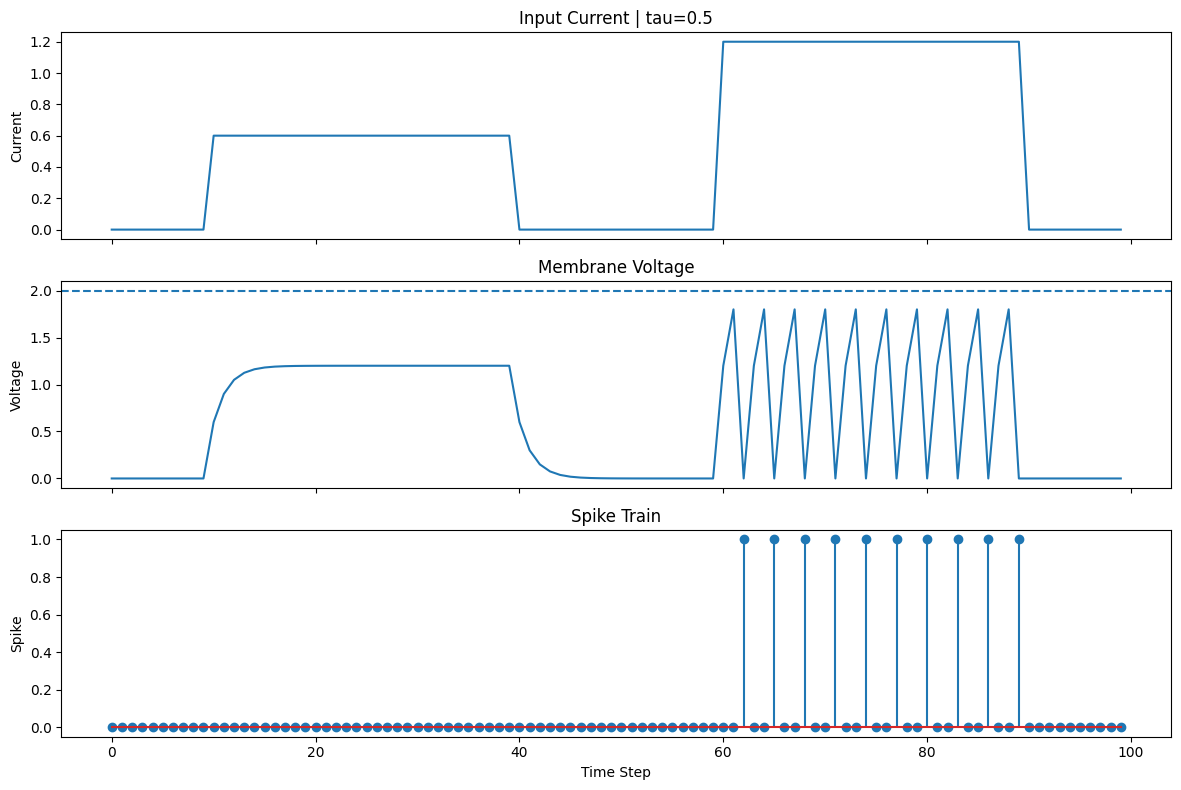

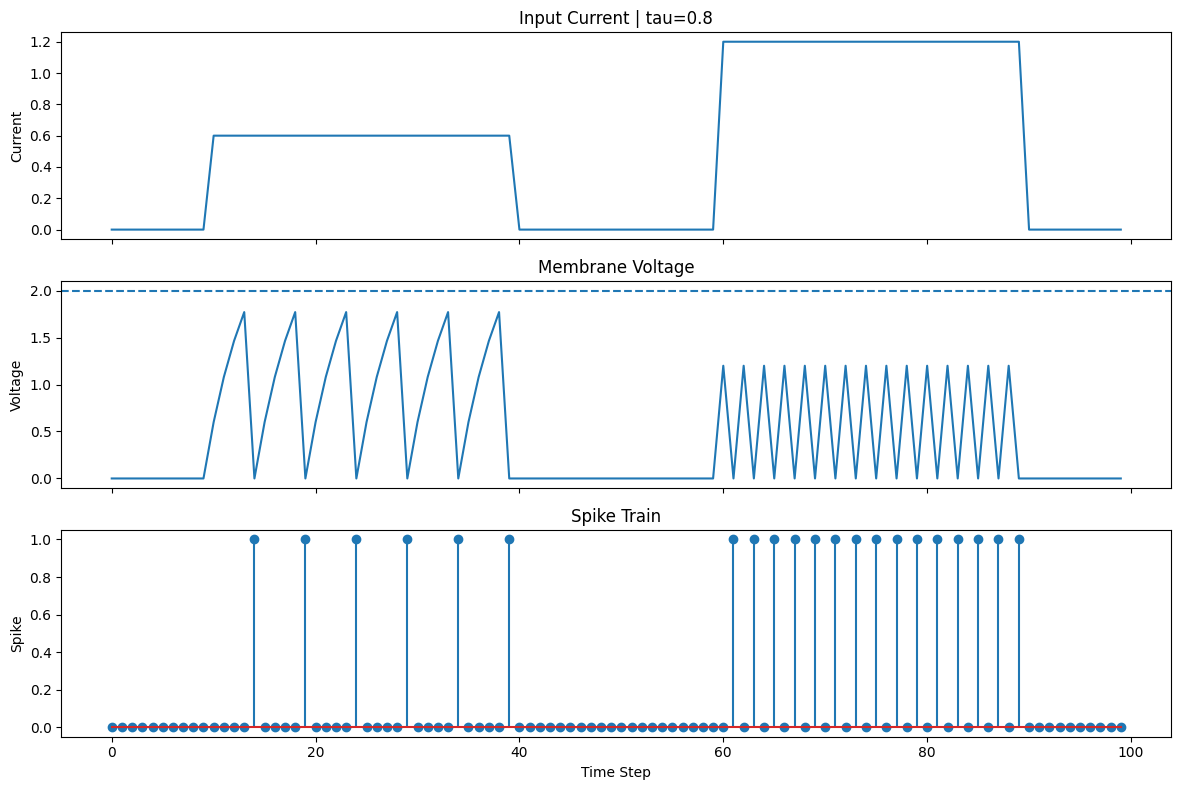

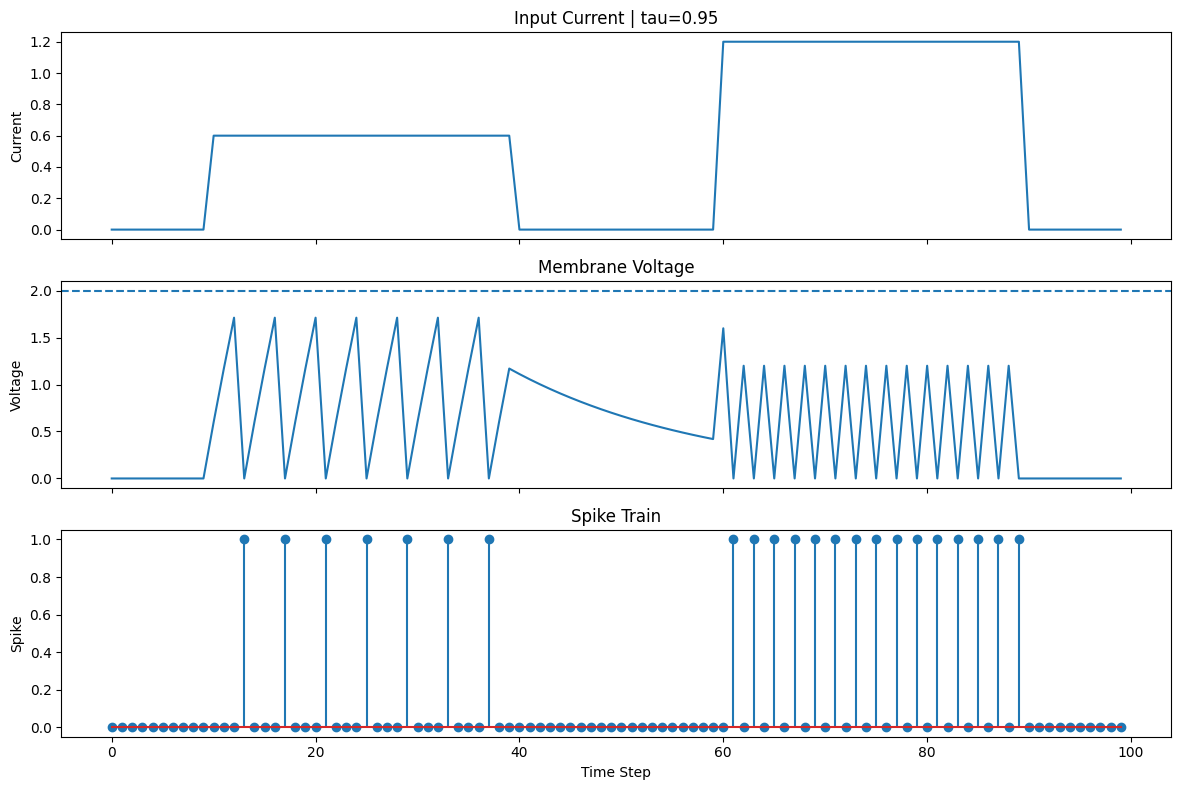

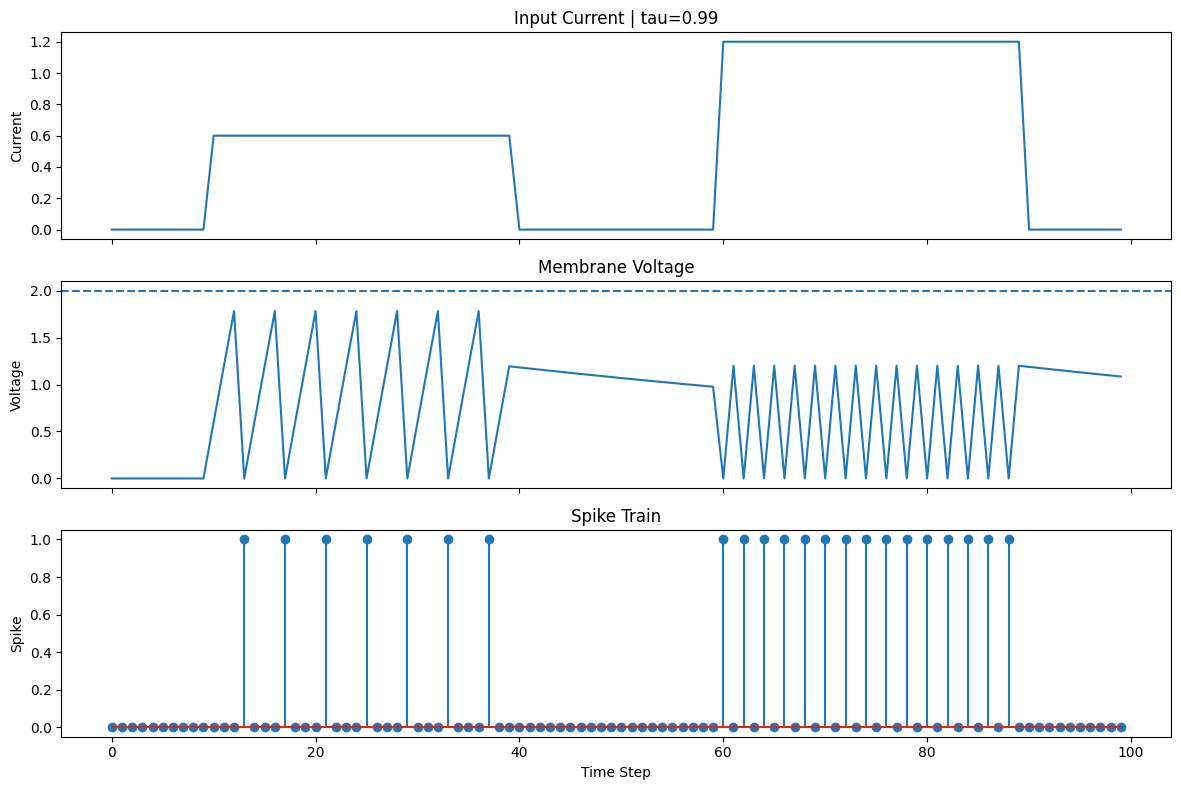

In [17]:
plot_results(tau=0.5)
plot_results(tau=0.8)
plot_results(tau=0.95)
plot_results(tau=0.99)